## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance, evaluate_with_solver, analyze_model_performance_solver
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import calculate_stats, build_transforms
from src.utils.plotting import visualize_test_samples, visualize_test_samples_with_solver, plot_training_history
from src.constants import CLASS_MAP
import numpy as np

In [3]:
# Load data 

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform, padding=1.0)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform, padding=1.0)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform, padding=1.0)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1800 | Test samples: 205
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 113/113 [00:31<00:00,  3.53it/s]



Calculated training mean: [0.7266303300857544, 0.6799918413162231, 0.5675383806228638]
Calculated training std:  [0.08976191282272339, 0.09742976725101471, 0.08831595629453659]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:04<00:00,  3.17it/s]


Calculated test mean: [0.7061654329299927, 0.6712028980255127, 0.5853357911109924]
Calculated test std:  [0.13416209816932678, 0.14039230346679688, 0.1279790848493576]



In [4]:
# Define ConvTransformer model

class ConvTransformer(nn.Module):
    def __init__(self, saved_model_path, num_classes=13, d_square=112, d_model=768, nhead=8, num_layers=4):
        super().__init__()
        
        self.backbone = torch.load(saved_model_path, weights_only=False)
        
        # Remove classification head
        self.backbone.classifier[2] = nn.Identity()
        
        # Freeze the backone
        self.backbone.eval() 
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Positional encoding
        self.pos_encoder = nn.Parameter(torch.randn(1, 64, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            batch_first=True,
            dropout=0.1
        )
        
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # New classification head
        self.classifier = nn.Linear(d_model, num_classes)

    
    def forward(self, x):
        if x.dim() == 5:
            B = x.size(0)
            x = x.view(B * 64, 3, d_square, d_square)
        elif x.dim() == 4:
            B = x.size(0) // 64
        else:
            raise ValueError(f"Unexpected input shape: {x.shape}")
        
        # Saved model forward pass
        with torch.no_grad():
            features = self.backbone(x)
            
        # Reshape for the Transformer Encoder
        features = features.view(B, 64, 768)
        
        # Add positional encoding
        features = features + self.pos_encoder
        
        # Pass through Transformer Encoder
        transformer_out = self.transformer(features)
        
        # Classification
        logits = self.classifier(transformer_out)
        
        return logits.view(B * 64, -1)

In [15]:
# Initialize model

model = ConvTransformer(os.path.join(project_root, 'models/convnext_new_data.pth')).to(device)

## Training

Training on cuda for 2 epochs...


Training Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2 | Train: Loss=0.0146 Acc=0.9965  Val: Loss=0.0006 Acc=0.9999   [Saved Best]
Epoch 2/2 | Train: Loss=0.0021 Acc=0.9996  Val: Loss=0.0004 Acc=0.9999  

Training complete in 1m 51s
Best Val Acc: 0.9999


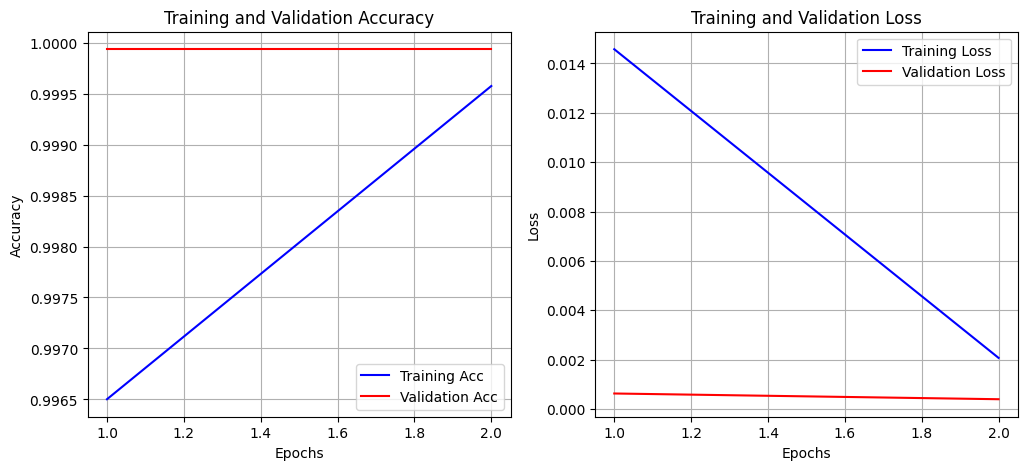

In [16]:
# Training loop

# Configuration
lr = 1e-4
num_epochs = 2
criterion = nn.CrossEntropyLoss()
params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(params, lr=lr)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'models/hybrid_new_data.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [17]:
# Evaluation on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 205 boards...


Evaluating:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 85.81
Board accuracy: 0.00


In [18]:
# Evaluation with solver on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate_with_solver(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Solver Evaluation on 205 boards...


Solver Inference:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 87.55
Board accuracy: 0.00


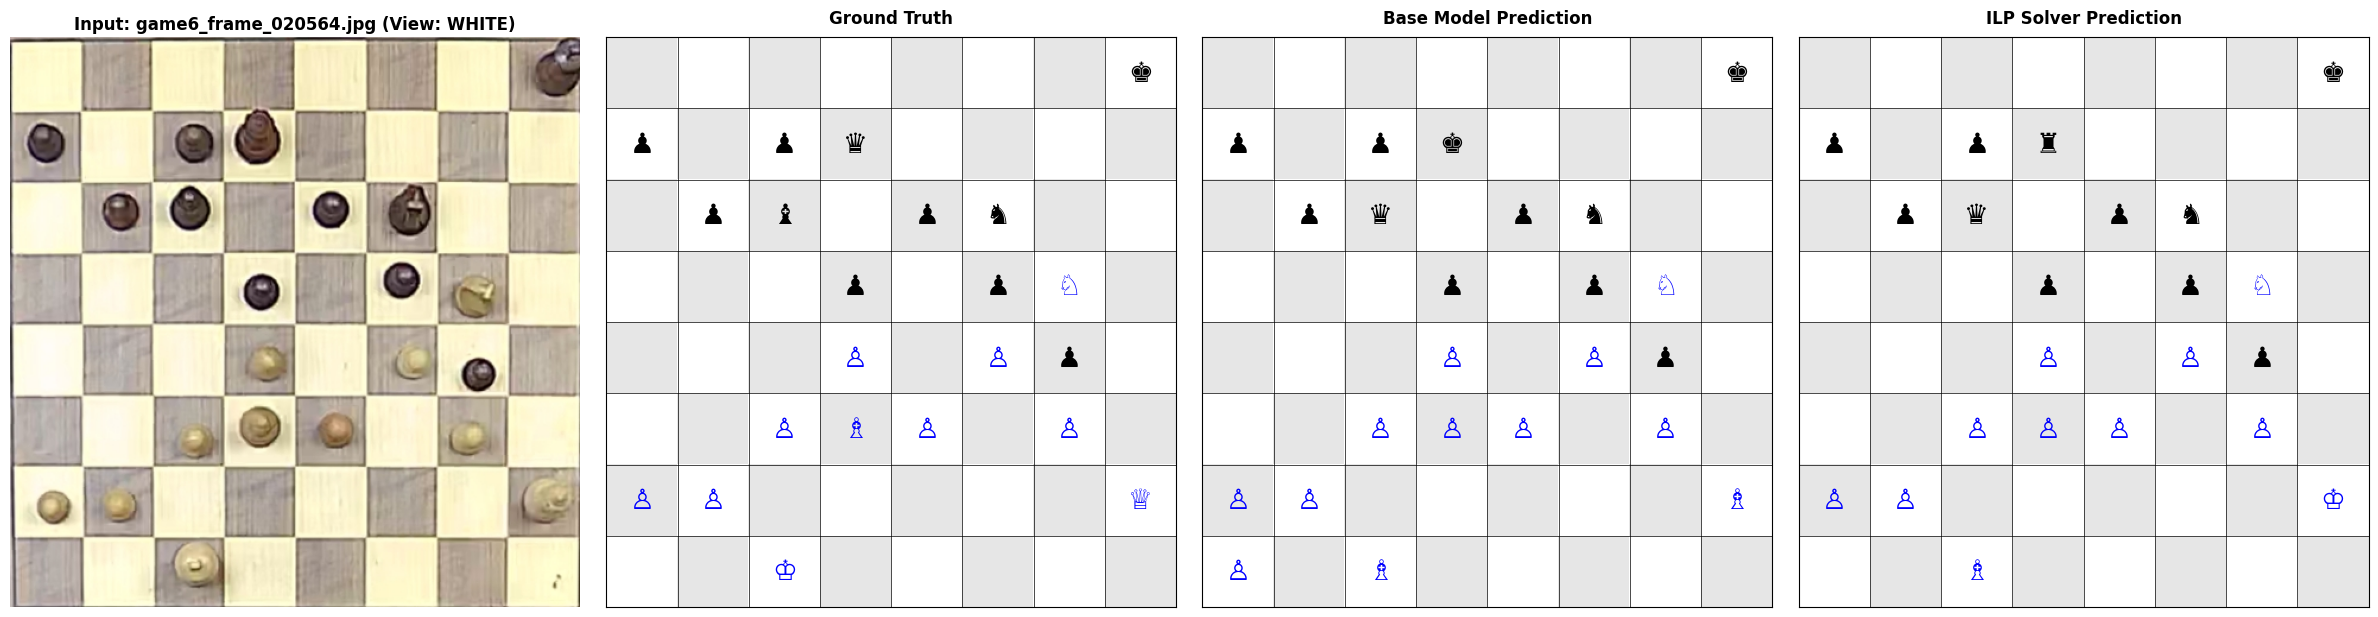

True FEN:   7k/p1pq4/1pb1pn2/3p1pN1/3P1Pp1/2PBP1P1/PP5Q/2K5
CNN FEN:    7k/p1pk4/1pq1pn2/3p1pN1/3P1Pp1/2PPP1P1/PP5B/P1B5
Solver FEN: 7k/p1pr4/1pq1pn2/3p1pN1/3P1Pp1/2PPP1P1/PP5K/2B5
MISMATCH ON BOTH



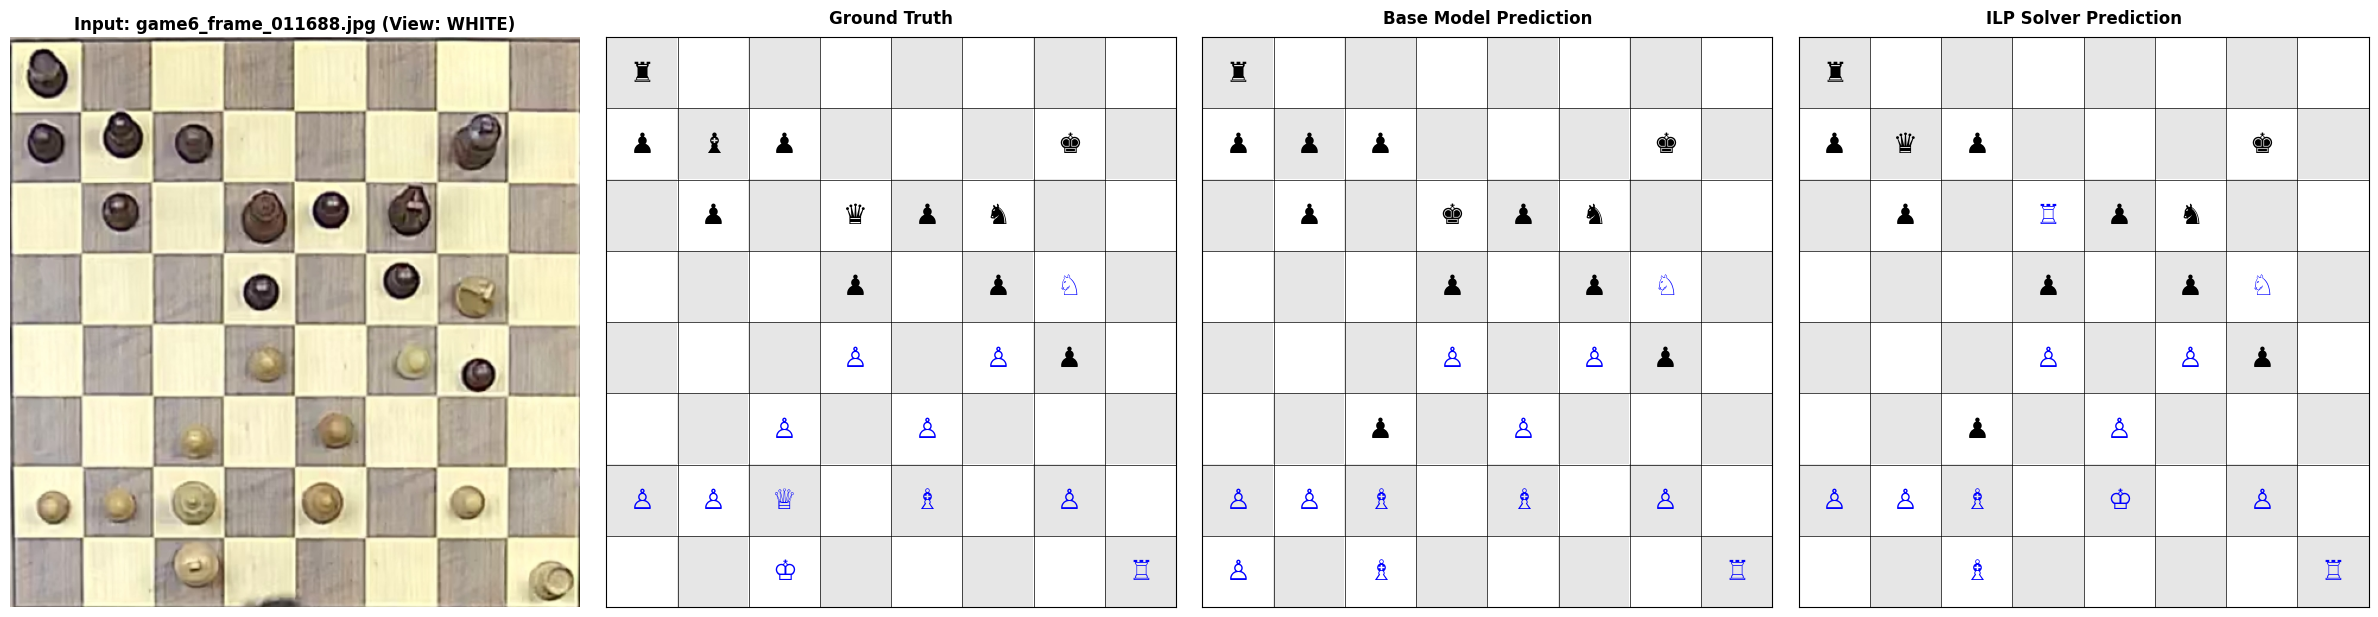

True FEN:   r7/pbp3k1/1p1qpn2/3p1pN1/3P1Pp1/2P1P3/PPQ1B1P1/2K4R
CNN FEN:    r7/ppp3k1/1p1kpn2/3p1pN1/3P1Pp1/2p1P3/PPB1B1P1/P1B4R
Solver FEN: r7/pqp3k1/1p1Rpn2/3p1pN1/3P1Pp1/2p1P3/PPB1K1P1/2B4R
MISMATCH ON BOTH



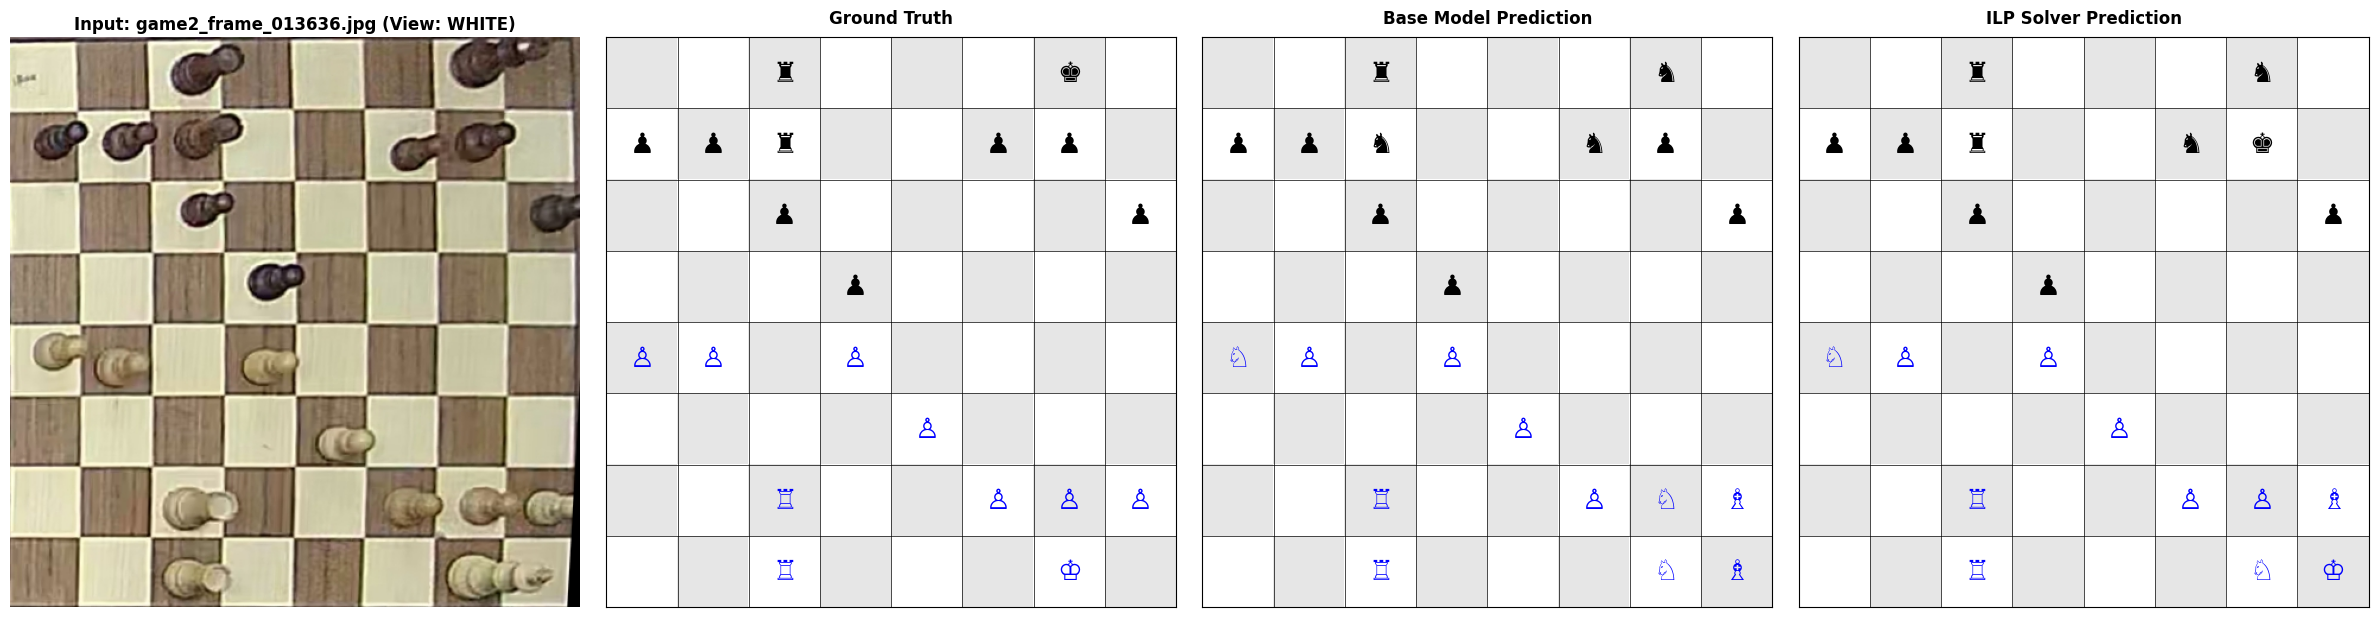

True FEN:   2r3k1/ppr2pp1/2p4p/3p4/PP1P4/4P3/2R2PPP/2R3K1
CNN FEN:    2r3n1/ppn2np1/2p4p/3p4/NP1P4/4P3/2R2PNB/2R3NB
Solver FEN: 2r3n1/ppr2nk1/2p4p/3p4/NP1P4/4P3/2R2PPB/2R3NK
MISMATCH ON BOTH



In [19]:
# Visualizing model with solver outputs

test_real_dataset.return_fen = True
visualize_test_samples_with_solver(best_model, test_real_dataset, num_samples=3, device=device)

Solver Inference:   0%|          | 0/103 [00:00<?, ?it/s]

Accuracy per Class:

white_pawn: 83.95% (1187/1414 correct)
white_rook: 74.73% (207/277 correct)
white_knight: 65.04% (147/226 correct)
white_bishop: 41.02% (105/256 correct)
white_queen: 7.02% (12/171 correct)
white_king: 25.37% (52/205 correct)
black_pawn: 83.38% (1169/1402 correct)
black_rook: 81.36% (240/295 correct)
black_knight: 76.42% (175/229 correct)
black_bishop: 25.51% (63/247 correct)
black_queen: 40.00% (68/170 correct)
black_king: 44.39% (91/205 correct)
empty     : 99.35% (7971/8023 correct)




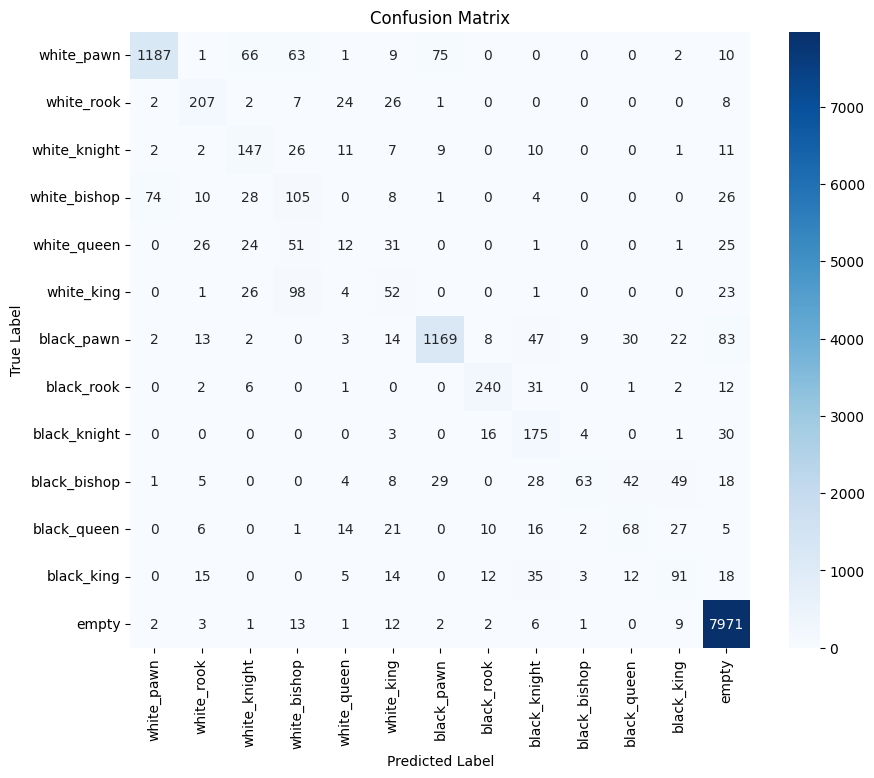

In [20]:
# Analyzing model with solver outputs and performance

class_names = list(CLASS_MAP.keys())
test_real_dataset.return_fen = False
analyze_model_performance_solver(best_model, test_real_loader, class_names, device)